# Music Genre Classification - EDA

## Preparation

### Import necessary libraries

In [2]:
import pandas as pd
from os.path import join
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

In [3]:
root_path = join("..", "..")
data_path = join(root_path, "data")
input_path = join(data_path, "raw")
output_path = join(data_path, "preprocessed")
train = pd.read_csv(join(input_path, "train.csv"))
test = pd.read_csv(join(input_path, "test.csv"))

train.head()

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5


From looking into the first 5 rows of the train dataset, we can see that there are a few missing values. Also, seems like there are only two features that contains letters.

## Have a look at the dataset

### Data description

- artist: Name of the Artist.
- song: Name of the Track.
- popularity: The higher the value the more popular the song is.
- danceability: Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm
- energy: Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity.
- key: The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on..
- loudness: The overall loudness of a track in decibels (dB). Loudness values are averaged across the entire track and are useful for comparing relative
- mode: Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0.
- speechiness: Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks.
- acousticness: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic.
- instrumentalness: Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content. Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0.
- liveness: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live.
- valence: A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry).
- tempo: The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration.
- duration in milliseconds :Time of the song
- time_signature : a notational convention used in Western musical notation to specify how many beats (pulses) are contained in each measure (bar), and which note value is equivalent to a beat.
- Class: Genre of the track.

- Artist: the popular the artist, the popular the some
- song: ?
- popularity: this could show which music genre is preffered by the audience => more song with the same genre will be published
- danceability: this could show the tempo of the music, base on this feature we could see if dance music is popular
- key: it could shows which keys that type of genre is more likely to be in
- loudness: 

### Detecting missing values

In [15]:
print("===== Number of missing values (train dataset) =====\n")
print(train[['Popularity', 'key', 'instrumentalness']].isnull().sum())
print('\n')
print("===== Number of missing values (test dataset) =====\n")
print(test[['Popularity', 'key', 'instrumentalness']].isnull().sum())

print("===== Percentage of missing values (train dataset) =====\n")
print(train[['Popularity', 'key', 'instrumentalness']].isnull().sum() / len(train) * 100)
print('\n')
print("===== Percentage of missing values (test dataset) =====\n")
print(test[['Popularity', 'key', 'instrumentalness']].isnull().sum() / len(test) * 100)

===== Number of missing values (train dataset) =====

Popularity           333
key                 1609
instrumentalness    3541
dtype: int64


===== Number of missing values (test dataset) =====

Popularity           95
key                 405
instrumentalness    836
dtype: int64
===== Percentage of missing values (train dataset) =====

Popularity           2.313143
key                 11.176716
instrumentalness    24.597110
dtype: float64


===== Percentage of missing values (test dataset) =====

Popularity           2.638889
key                 11.250000
instrumentalness    23.222222
dtype: float64


## EDA Analysis

### Univariate analysis

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14396 non-null  int64  
 1   Artist Name         14396 non-null  object 
 2   Track Name          14396 non-null  object 
 3   Popularity          14063 non-null  float64
 4   danceability        14396 non-null  float64
 5   energy              14396 non-null  float64
 6   key                 12787 non-null  float64
 7   loudness            14396 non-null  float64
 8   mode                14396 non-null  int64  
 9   speechiness         14396 non-null  float64
 10  acousticness        14396 non-null  float64
 11  instrumentalness    10855 non-null  float64
 12  liveness            14396 non-null  float64
 13  valence             14396 non-null  float64
 14  tempo               14396 non-null  float64
 15  duration_in min/ms  14396 non-null  float64
 16  time

In [13]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  3600 non-null   int64  
 1   Artist Name         3600 non-null   object 
 2   Track Name          3600 non-null   object 
 3   Popularity          3505 non-null   float64
 4   danceability        3600 non-null   float64
 5   energy              3600 non-null   float64
 6   key                 3195 non-null   float64
 7   loudness            3600 non-null   float64
 8   mode                3600 non-null   int64  
 9   speechiness         3600 non-null   float64
 10  acousticness        3600 non-null   float64
 11  instrumentalness    2764 non-null   float64
 12  liveness            3600 non-null   float64
 13  valence             3600 non-null   float64
 14  tempo               3600 non-null   float64
 15  duration_in min/ms  3600 non-null   float64
 16  time_s

Based on the output, we could see that:
- There are features that contains missing values on both datasets (Popularity, key, instrumentalness)
- Two variables that contains letters (Artist Name, Track Name)

The percentage of missing values on three features are shown in "Detecting missing values"

In [12]:
# Check unique values for each feature in train dataset, excluding 'Artist Name' and 'Track Name'

print("===== Unique values on train dataset =====")
total_unique_train = 0
for col in train.columns:
    if col not in ['Artist Name', 'Track Name']:
        unique_vals = train[col].dropna().unique()
        num_unique = len(unique_vals)
        total_unique_train += num_unique
        print(f"{col}: {num_unique} unique values")  # Showing first 10 unique values for brevity

# Similarly for test dataset
print("\n===== Unique values on test dataset =====")
total_unique_test = 0
for col in test.columns:
    if col not in ['Artist Name', 'Track Name']:
        unique_vals = test[col].dropna().unique()
        num_unique = len(unique_vals)
        total_unique_test += num_unique
        print(f"{col}: {num_unique} unique values")  # Showing first 10 unique values for brevity

===== Unique values on train dataset =====
Id: 14396 unique values
Popularity: 100 unique values
danceability: 887 unique values
energy: 1156 unique values
key: 11 unique values
loudness: 8051 unique values
mode: 2 unique values
speechiness: 1177 unique values
acousticness: 3725 unique values
instrumentalness: 3945 unique values
liveness: 1407 unique values
valence: 1268 unique values
tempo: 11392 unique values
duration_in min/ms: 11805 unique values
time_signature: 4 unique values
Class: 11 unique values

===== Unique values on test dataset =====
Id: 3600 unique values
Popularity: 95 unique values
danceability: 758 unique values
energy: 890 unique values
key: 11 unique values
loudness: 3010 unique values
mode: 2 unique values
speechiness: 939 unique values
acousticness: 2050 unique values
instrumentalness: 1940 unique values
liveness: 951 unique values
valence: 995 unique values
tempo: 3353 unique values
duration_in min/ms: 3380 unique values
time_signature: 4 unique values


Based on the total number of unique values inside each features, it is likely that there are four categorical features (key, mode, time_signature and Class)

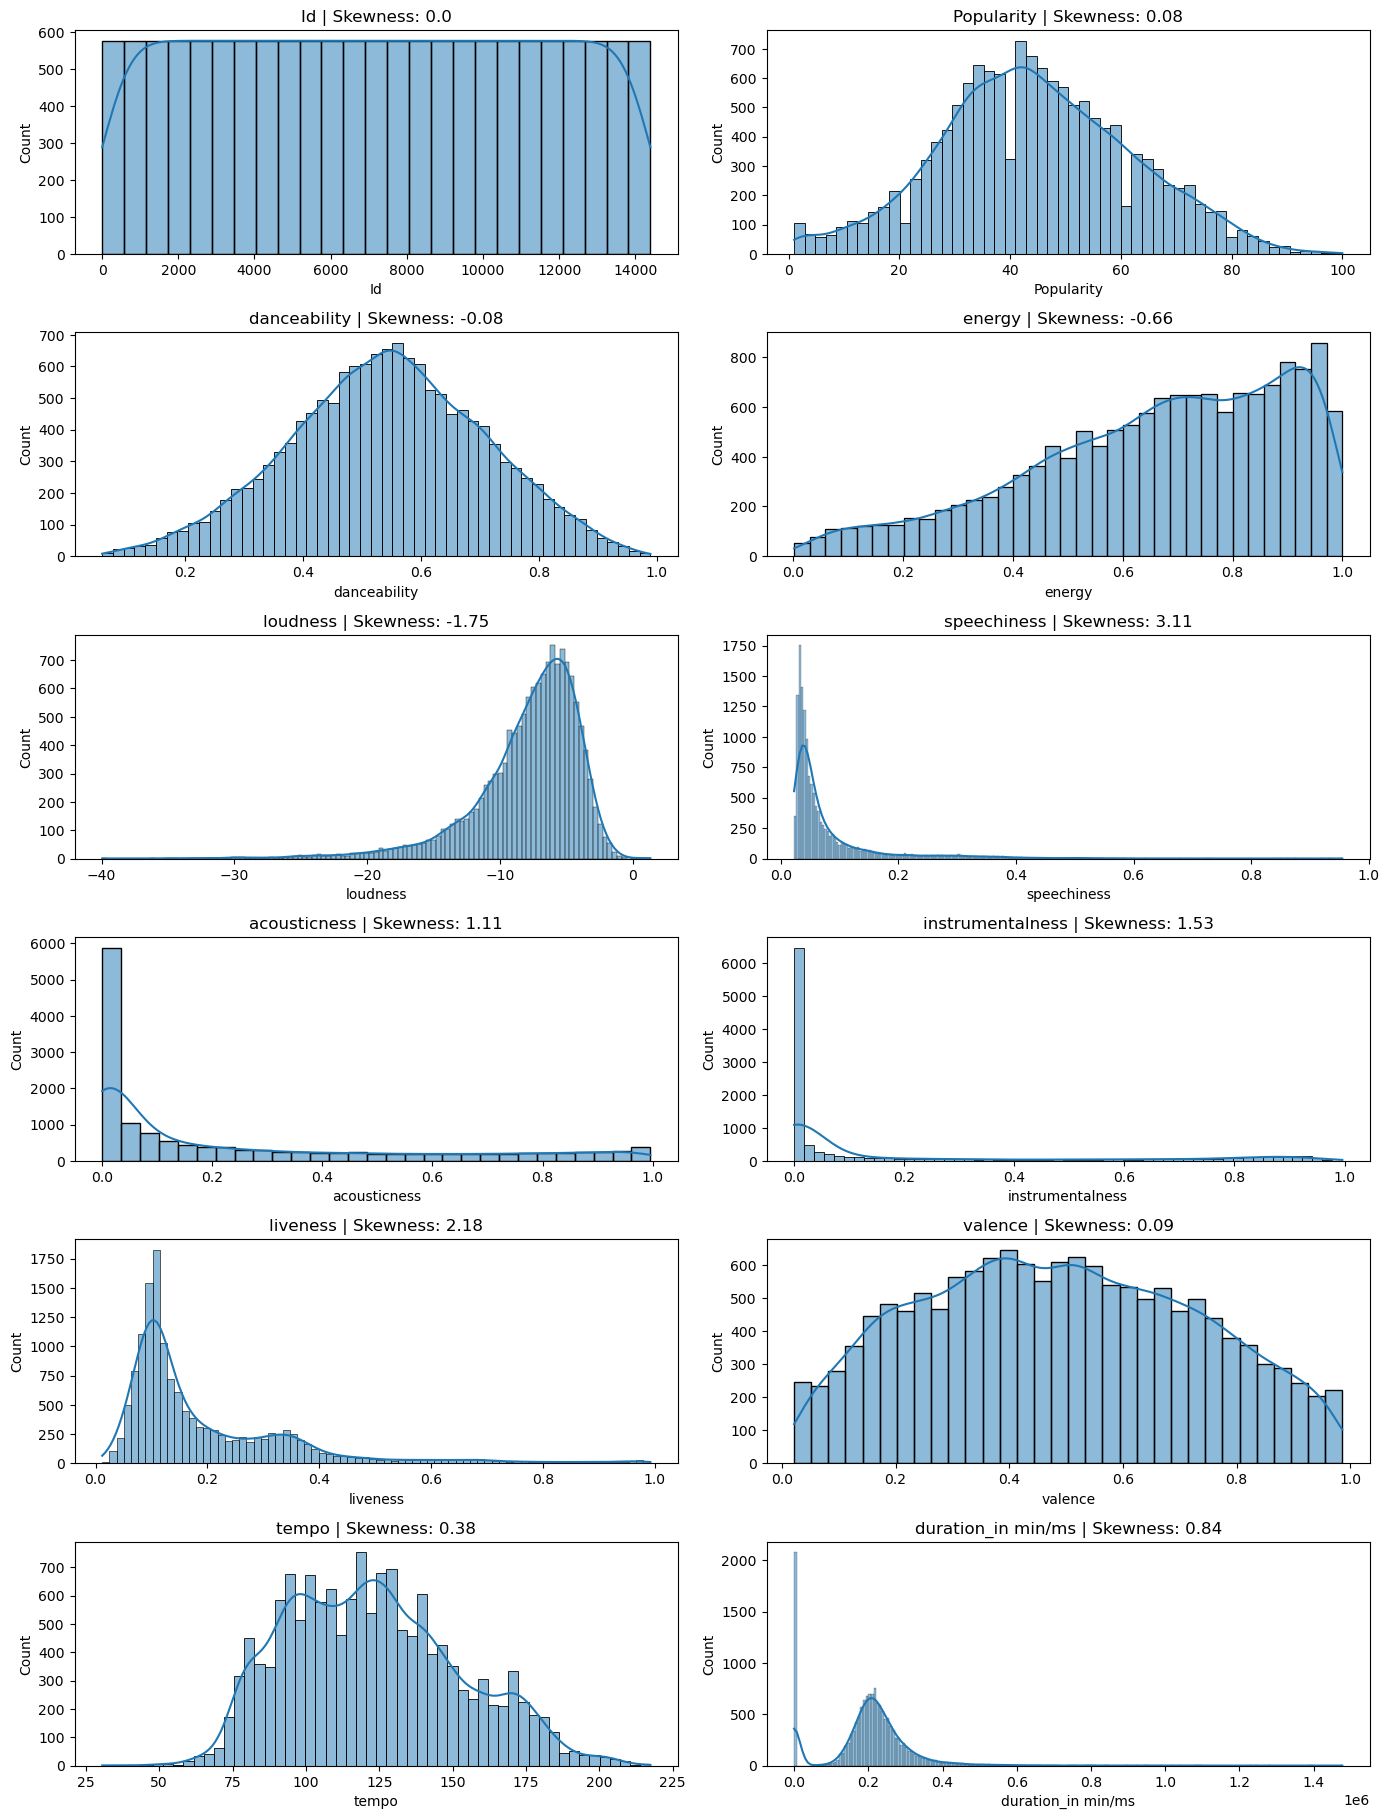

In [18]:
numerical_columns = train.drop(['key', 'mode', 'time_signature', 'Class'], axis=1).select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(train[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(train[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

Usually, features that have abs(skewness) > 2 are considered skewed. However, for the accuracy of the model, we will consider re-scale features that have asb(skewness) > 1
Those features are:
- loudness
- speechiness
- acousticness
- instrumentalness
- liveness

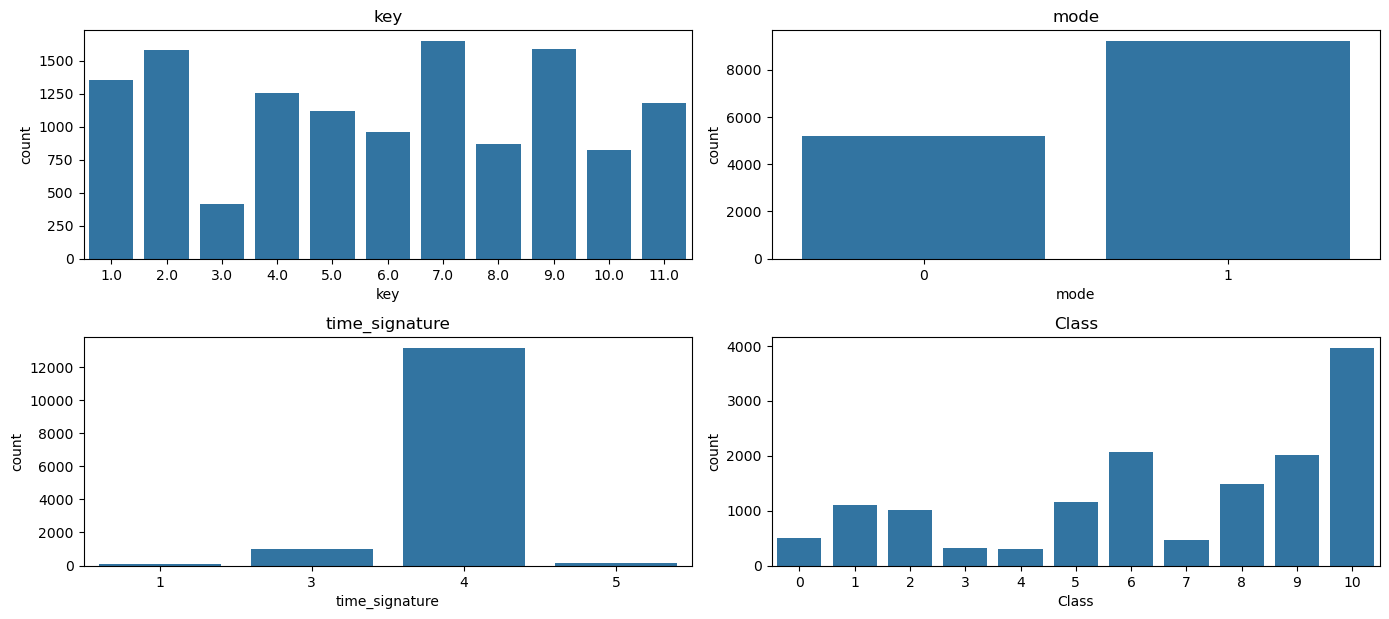

In [ ]:
categorical_columns = ['key', 'mode', 'time_signature', 'Class']
plt.figure(figsize=(14, len(categorical_columns) * 3))
for idx, feature in enumerate(categorical_columns, 1):
    plt.subplot(len(categorical_columns), 2, idx)
    sns.countplot(data=train, x=feature)
    plt.title(f"{feature}")

plt.tight_layout()
plt.show()

- Most of the track have time_signature = 4
- two thirds of the train dataset have mode = 1
- not too much tracks have key = 3
- Class = 10 have the highest number of tracks

### Bivariate Analysis

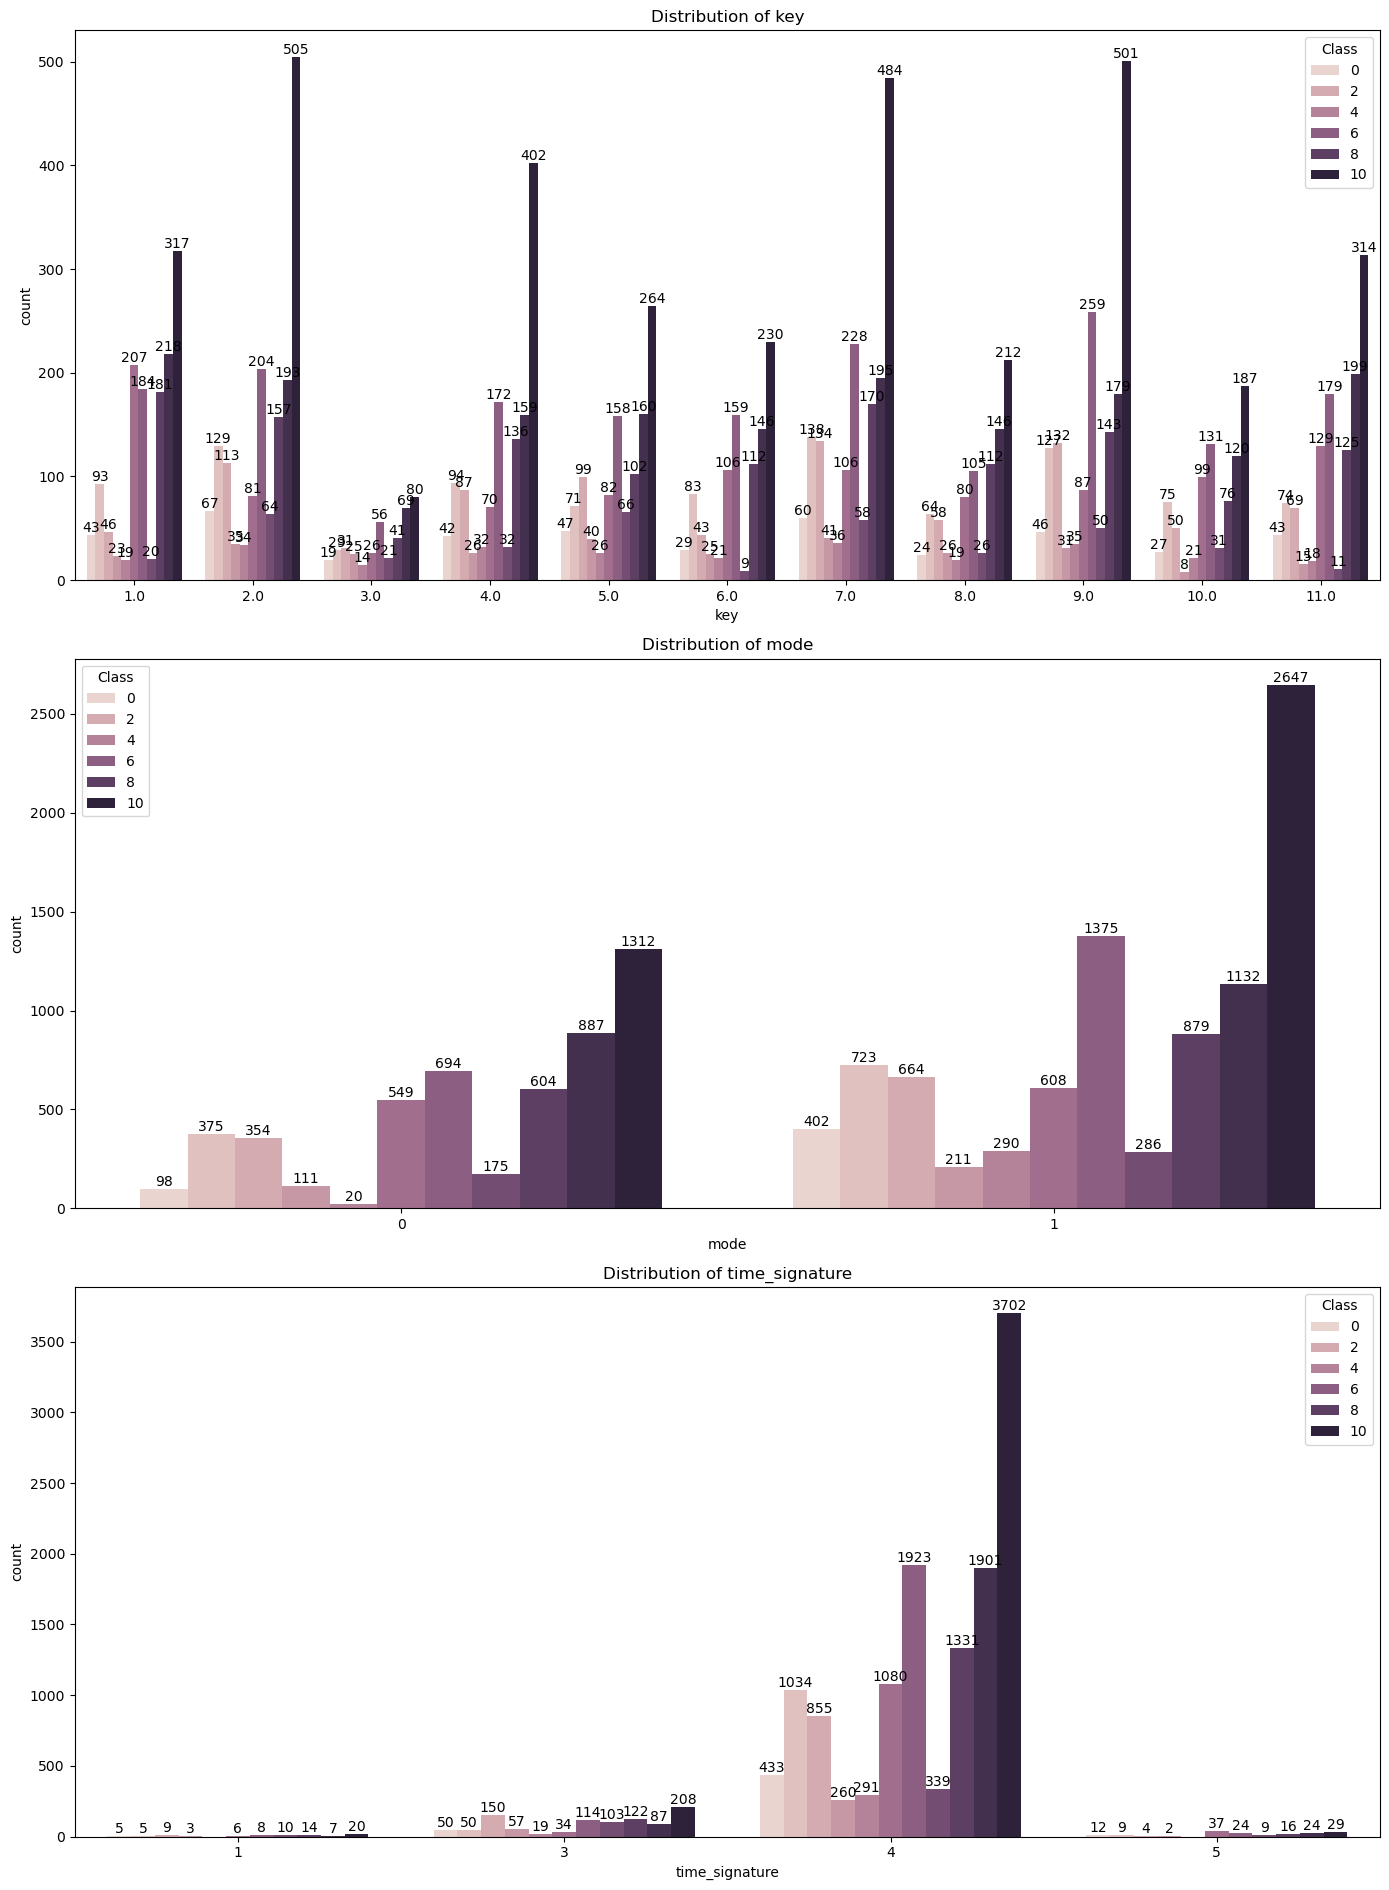

In [32]:
plt.figure(figsize=(14, len(categorical_columns) * 3 + 10))
for idx, feature in enumerate(categorical_columns, 1):
    # print(feature)
    plt.subplot(len(categorical_columns), 1, idx)
    sns.countplot(data=train, x=feature, hue='Class')
    plt.title('Distribution of ' + feature)
    ax = plt.gca()
    for container in ax.containers:
        ax.bar_label(container)    

plt.tight_layout()
plt.show()

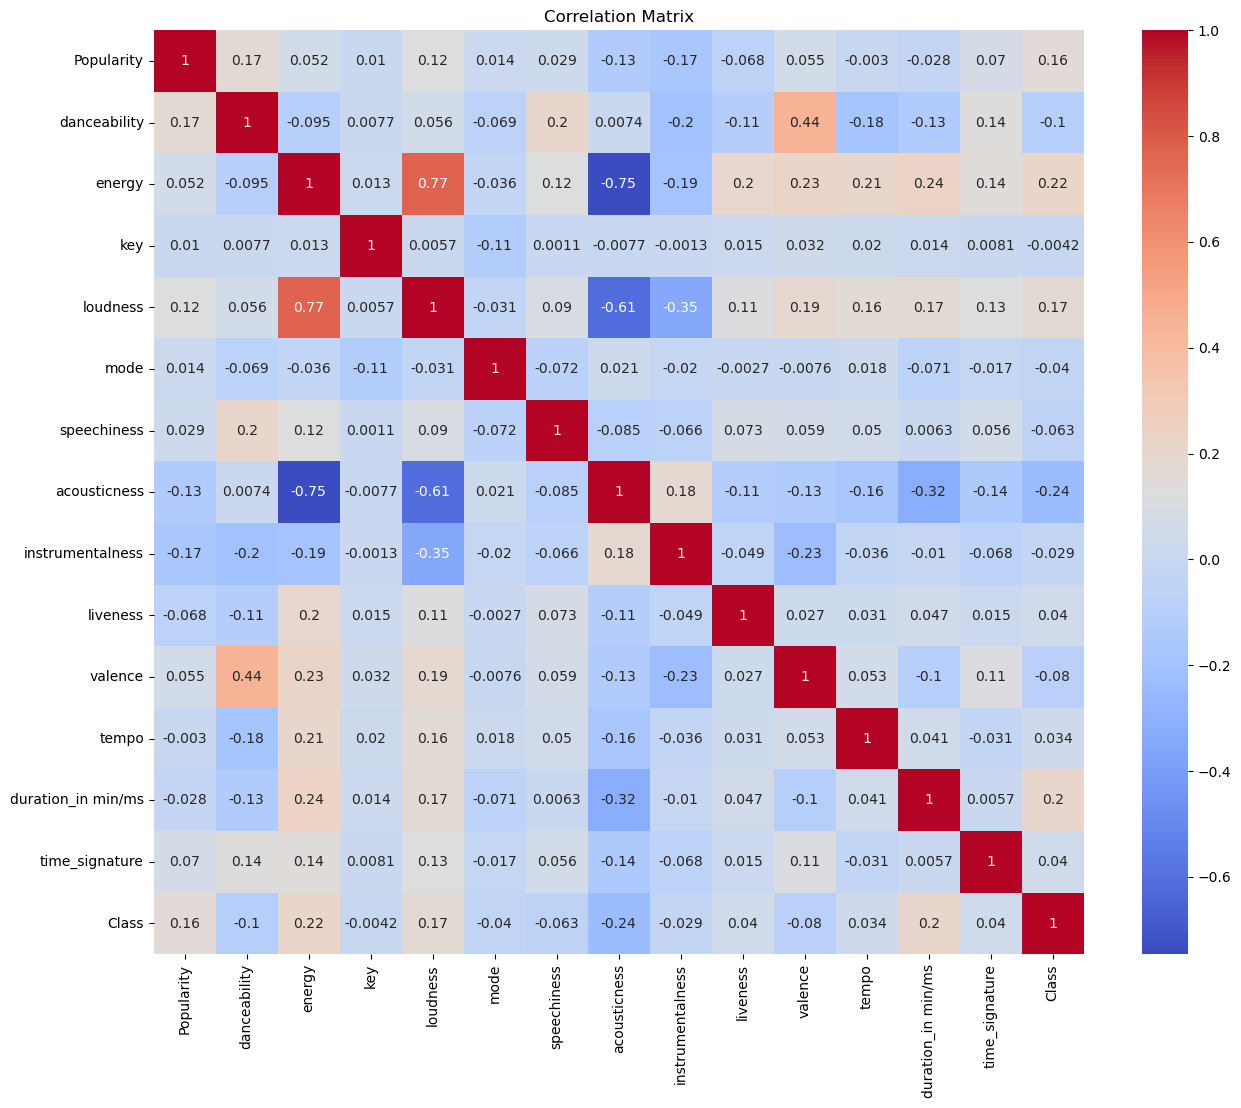

In [30]:
plt.figure(figsize=(15,12))
sns.heatmap(train.drop(['Artist Name', 'Track Name', 'Id'], axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()